In [2]:
import pandas as pd

# CSV dosyasını oku
df = pd.read_csv("HeartDiseaseTrain-Test.csv")

# İlk 5 satırı göster
print("İlk 5 satır:")
print(df.head())

# Veri boyutu
print("\nVeri boyutu:")
print(df.shape)

# Sütun isimleri
print("\nSütun isimleri:")
print(df.columns.tolist())

# Veri tipleri
print("\nVeri tipleri:")
print(df.dtypes)

İlk 5 satır:
   age     sex chest_pain_type  resting_blood_pressure  cholestoral  \
0   52    Male  Typical angina                     125          212   
1   53    Male  Typical angina                     140          203   
2   70    Male  Typical angina                     145          174   
3   61    Male  Typical angina                     148          203   
4   62  Female  Typical angina                     138          294   

      fasting_blood_sugar               rest_ecg  Max_heart_rate  \
0    Lower than 120 mg/ml  ST-T wave abnormality             168   
1  Greater than 120 mg/ml                 Normal             155   
2    Lower than 120 mg/ml  ST-T wave abnormality             125   
3    Lower than 120 mg/ml  ST-T wave abnormality             161   
4  Greater than 120 mg/ml  ST-T wave abnormality             106   

  exercise_induced_angina  oldpeak        slope vessels_colored_by_flourosopy  \
0                      No      1.0  Downsloping                       

In [3]:
# sütun isimlerini küçük harfe çevir ve boşlukları kaldır
df.columns = df.columns.str.lower().str.strip().str.replace(" ", "_")

print("Yeni sütun isimleri:")
print(df.columns)

# tekrar eden satır kontrolü
duplicates = df.duplicated().sum()
print("\nTekrar eden satır sayısı:", duplicates)

# varsa sil
df = df.drop_duplicates()

print("Yeni veri boyutu:", df.shape)

# eksik veri kontrolü
print("\nEksik veri sayıları:")
print(df.isnull().sum())

Yeni sütun isimleri:
Index(['age', 'sex', 'chest_pain_type', 'resting_blood_pressure',
       'cholestoral', 'fasting_blood_sugar', 'rest_ecg', 'max_heart_rate',
       'exercise_induced_angina', 'oldpeak', 'slope',
       'vessels_colored_by_flourosopy', 'thalassemia', 'target'],
      dtype='str')

Tekrar eden satır sayısı: 723
Yeni veri boyutu: (302, 14)

Eksik veri sayıları:
age                              0
sex                              0
chest_pain_type                  0
resting_blood_pressure           0
cholestoral                      0
fasting_blood_sugar              0
rest_ecg                         0
max_heart_rate                   0
exercise_induced_angina          0
oldpeak                          0
slope                            0
vessels_colored_by_flourosopy    0
thalassemia                      0
target                           0
dtype: int64


In [4]:
# özellikler
X = df.drop("target", axis=1)

# hedef değişken
y = df["target"]

print("X boyutu:", X.shape)
print("y boyutu:", y.shape)

print("\nTarget dağılımı:")
print(y.value_counts())

X boyutu: (302, 13)
y boyutu: (302,)

Target dağılımı:
target
1    164
0    138
Name: count, dtype: int64


In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Train set boyutu:", X_train.shape)
print("Test set boyutu:", X_test.shape)

print("\nTrain target dağılımı:")
print(y_train.value_counts())

print("\nTest target dağılımı:")
print(y_test.value_counts())

Train set boyutu: (241, 13)
Test set boyutu: (61, 13)

Train target dağılımı:
target
1    131
0    110
Name: count, dtype: int64

Test target dağılımı:
target
1    33
0    28
Name: count, dtype: int64


In [6]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "string"]).columns.tolist()

print("Sayısal sütunlar:")
print(numeric_features)

print("\nKategorik sütunlar:")
print(categorical_features)

Sayısal sütunlar:
['age', 'resting_blood_pressure', 'cholestoral', 'max_heart_rate', 'oldpeak']

Kategorik sütunlar:
['sex', 'chest_pain_type', 'fasting_blood_sugar', 'rest_ecg', 'exercise_induced_angina', 'slope', 'vessels_colored_by_flourosopy', 'thalassemia']


In [7]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder

numeric_transformer = Pipeline(steps=[
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

print("Preprocessing yapısı hazır.")
print(preprocessor)

Preprocessing yapısı hazır.
ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('scaler', StandardScaler())]),
                                 ['age', 'resting_blood_pressure',
                                  'cholestoral', 'max_heart_rate', 'oldpeak']),
                                ('cat',
                                 Pipeline(steps=[('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['sex', 'chest_pain_type',
                                  'fasting_blood_sugar', 'rest_ecg',
                                  'exercise_induced_angina', 'slope',
                                  'vessels_colored_by_flourosopy',
                                  'thalassemia'])])


In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report

# pipeline kur
logistic_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])

# modeli eğit
logistic_pipeline.fit(X_train, y_train)

# tahmin yap
y_pred = logistic_pipeline.predict(X_test)

# accuracy
acc = accuracy_score(y_test, y_pred)

print("Logistic Regression Accuracy:", acc)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Logistic Regression Accuracy: 0.8360655737704918

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.82      0.82        28
           1       0.85      0.85      0.85        33

    accuracy                           0.84        61
   macro avg       0.83      0.83      0.83        61
weighted avg       0.84      0.84      0.84        61



In [9]:
from sklearn.tree import DecisionTreeClassifier

# pipeline
tree_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(random_state=42))
])

# eğitim
tree_pipeline.fit(X_train, y_train)

# tahmin
y_pred_tree = tree_pipeline.predict(X_test)

# sonuçlar
acc_tree = accuracy_score(y_test, y_pred_tree)

print("Decision Tree Accuracy:", acc_tree)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_tree))

Decision Tree Accuracy: 0.7213114754098361

Classification Report:
              precision    recall  f1-score   support

           0       0.68      0.75      0.71        28
           1       0.77      0.70      0.73        33

    accuracy                           0.72        61
   macro avg       0.72      0.72      0.72        61
weighted avg       0.73      0.72      0.72        61



In [10]:
from sklearn.svm import SVC

svm_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", SVC())
])

svm_pipeline.fit(X_train, y_train)

y_pred_svm = svm_pipeline.predict(X_test)

acc_svm = accuracy_score(y_test, y_pred_svm)

print("SVM Accuracy:", acc_svm)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm))

SVM Accuracy: 0.7868852459016393

Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.79      0.77        28
           1       0.81      0.79      0.80        33

    accuracy                           0.79        61
   macro avg       0.79      0.79      0.79        61
weighted avg       0.79      0.79      0.79        61



In [11]:
from sklearn.ensemble import RandomForestClassifier

rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(random_state=42))
])

rf_pipeline.fit(X_train, y_train)

y_pred_rf = rf_pipeline.predict(X_test)

acc_rf = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", acc_rf)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.7868852459016393

Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.79      0.77        28
           1       0.81      0.79      0.80        33

    accuracy                           0.79        61
   macro avg       0.79      0.79      0.79        61
weighted avg       0.79      0.79      0.79        61



In [12]:
from sklearn.neighbors import KNeighborsClassifier

knn_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", KNeighborsClassifier())
])

knn_pipeline.fit(X_train, y_train)

y_pred_knn = knn_pipeline.predict(X_test)

print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn))

KNN Accuracy: 0.8360655737704918
              precision    recall  f1-score   support

           0       0.80      0.86      0.83        28
           1       0.87      0.82      0.84        33

    accuracy                           0.84        61
   macro avg       0.84      0.84      0.84        61
weighted avg       0.84      0.84      0.84        61



In [13]:
from sklearn.ensemble import GradientBoostingClassifier

gb_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", GradientBoostingClassifier())
])

gb_pipeline.fit(X_train, y_train)

y_pred_gb = gb_pipeline.predict(X_test)

print("Gradient Boosting Accuracy:", accuracy_score(y_test, y_pred_gb))
print(classification_report(y_test, y_pred_gb))

Gradient Boosting Accuracy: 0.7704918032786885
              precision    recall  f1-score   support

           0       0.75      0.75      0.75        28
           1       0.79      0.79      0.79        33

    accuracy                           0.77        61
   macro avg       0.77      0.77      0.77        61
weighted avg       0.77      0.77      0.77        61



In [14]:
models = {
    "Logistic Regression": logistic_pipeline,
    "Decision Tree": tree_pipeline,
    "SVM": svm_pipeline,
    "Random Forest": rf_pipeline,
    "KNN": knn_pipeline
}

In [15]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
import numpy as np

results = {}

for model_name, model in models.items():
    
    scores_list = []

    for i in range(10):

        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=i)

        scores = cross_val_score(
            model,
            X_train,
            y_train,
            cv=cv,
            scoring="accuracy"
        )

        scores_list.append(scores.mean())

    results[model_name] = scores_list

In [16]:
for model, scores in results.items():
    
    mean_score = np.mean(scores)
    std_score = np.std(scores)

    print(f"{model}")
    print("Mean Accuracy:", round(mean_score,3))
    print("Std:", round(std_score,3))
    print()

Logistic Regression
Mean Accuracy: 0.847
Std: 0.008

Decision Tree
Mean Accuracy: 0.756
Std: 0.015

SVM
Mean Accuracy: 0.845
Std: 0.014

Random Forest
Mean Accuracy: 0.838
Std: 0.013

KNN
Mean Accuracy: 0.841
Std: 0.011



In [17]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

models_predictions = {
    "Logistic Regression": y_pred,
    "Decision Tree": y_pred_tree,
    "SVM": y_pred_svm,
    "Random Forest": y_pred_rf,
    "KNN": y_pred_knn
}

results_table = []

for model_name, preds in models_predictions.items():
    
    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds)
    rec = recall_score(y_test, preds)
    f1 = f1_score(y_test, preds)
    
    results_table.append({
        "Model": model_name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-score": f1
    })

results_df = pd.DataFrame(results_table)

results_df = results_df.sort_values(by="Accuracy", ascending=False)

results_df = results_df.round(3)

print(results_df)

                 Model  Accuracy  Precision  Recall  F1-score
0  Logistic Regression     0.836      0.848   0.848     0.848
4                  KNN     0.836      0.871   0.818     0.844
2                  SVM     0.787      0.812   0.788     0.800
3        Random Forest     0.787      0.812   0.788     0.800
1        Decision Tree     0.721      0.767   0.697     0.730


In [18]:
print(df.shape)
print(df.columns.tolist())
print(df.head())
print(df.info())
print(df.isnull().sum())
print(df['target'].value_counts())
print(df.describe())

(302, 14)
['age', 'sex', 'chest_pain_type', 'resting_blood_pressure', 'cholestoral', 'fasting_blood_sugar', 'rest_ecg', 'max_heart_rate', 'exercise_induced_angina', 'oldpeak', 'slope', 'vessels_colored_by_flourosopy', 'thalassemia', 'target']
   age     sex chest_pain_type  resting_blood_pressure  cholestoral  \
0   52    Male  Typical angina                     125          212   
1   53    Male  Typical angina                     140          203   
2   70    Male  Typical angina                     145          174   
3   61    Male  Typical angina                     148          203   
4   62  Female  Typical angina                     138          294   

      fasting_blood_sugar               rest_ecg  max_heart_rate  \
0    Lower than 120 mg/ml  ST-T wave abnormality             168   
1  Greater than 120 mg/ml                 Normal             155   
2    Lower than 120 mg/ml  ST-T wave abnormality             125   
3    Lower than 120 mg/ml  ST-T wave abnormality          

In [19]:
print(df['target'].value_counts())

target
1    164
0    138
Name: count, dtype: int64


In [20]:
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report

svm_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", SVC(probability=True, random_state=42))
])

svm_pipeline.fit(X_train, y_train)

y_pred_svm = svm_pipeline.predict(X_test)

acc_svm = accuracy_score(y_test, y_pred_svm)

print("SVM Accuracy:", acc_svm)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm))

SVM Accuracy: 0.7868852459016393

Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.79      0.77        28
           1       0.81      0.79      0.80        33

    accuracy                           0.79        61
   macro avg       0.79      0.79      0.79        61
weighted avg       0.79      0.79      0.79        61



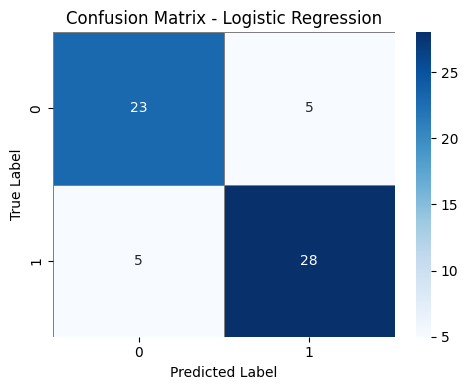

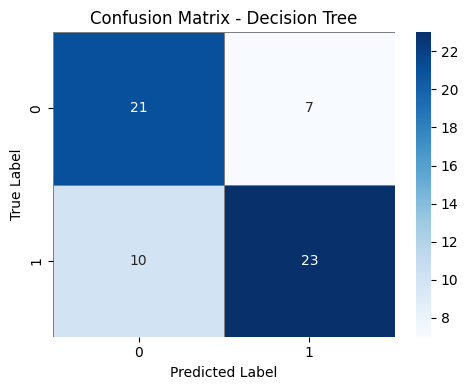

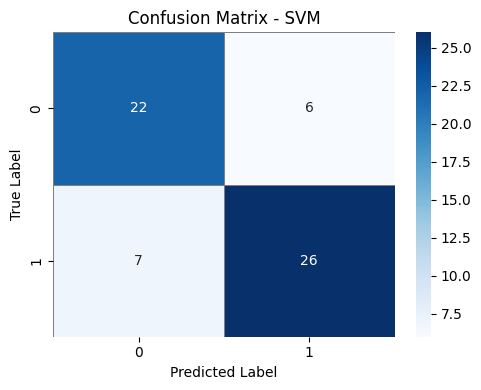

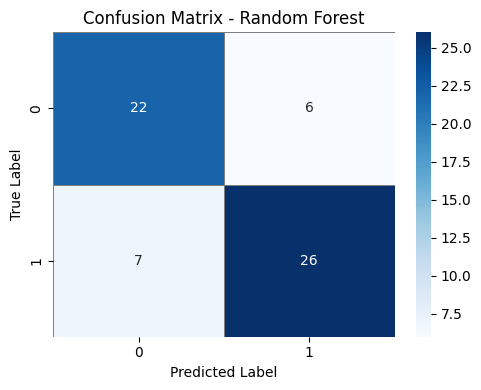

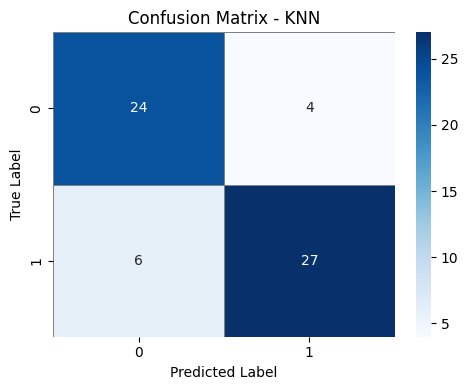

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

models_preds = {
    "Logistic Regression": y_pred,
    "Decision Tree": y_pred_tree,
    "SVM": y_pred_svm,
    "Random Forest": y_pred_rf,
    "KNN": y_pred_knn
}

for model_name, preds in models_preds.items():
    cm = confusion_matrix(y_test, preds)

    plt.figure(figsize=(5, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=True,
        linewidths=0.5,
        linecolor="gray"
    )
    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.tight_layout()
    plt.show()

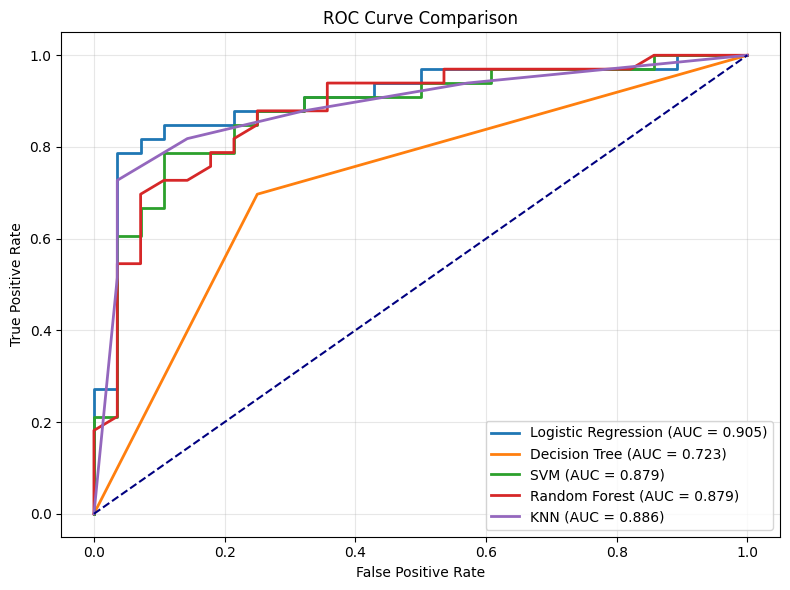

In [22]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

trained_models = {
    "Logistic Regression": logistic_pipeline,
    "Decision Tree": tree_pipeline,
    "SVM": svm_pipeline,
    "Random Forest": rf_pipeline,
    "KNN": knn_pipeline
}

plt.figure(figsize=(8, 6))

for model_name, model in trained_models.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, linewidth=2, label=f"{model_name} (AUC = {roc_auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="navy", linewidth=1.5)

plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

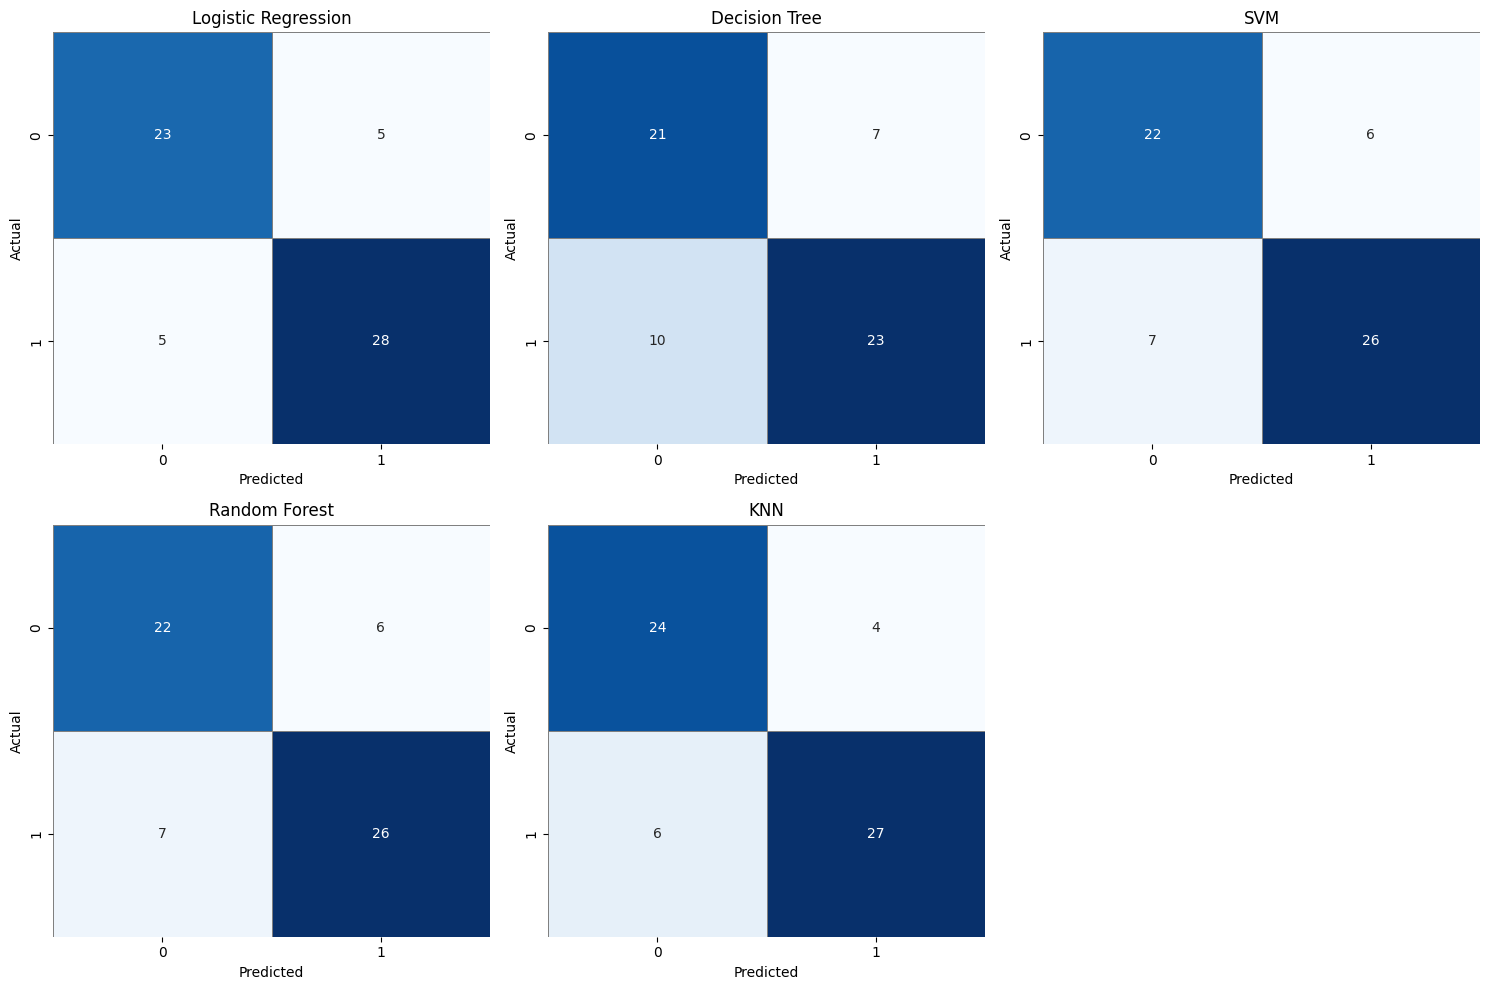

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

models_preds = {
    "Logistic Regression": y_pred,
    "Decision Tree": y_pred_tree,
    "SVM": y_pred_svm,
    "Random Forest": y_pred_rf,
    "KNN": y_pred_knn
}

# subplot düzeni (2 satır 3 sütun)
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, (model_name, preds) in enumerate(models_preds.items()):
    cm = confusion_matrix(y_test, preds)

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        linewidths=0.5,
        linecolor="gray",
        ax=axes[i]
    )
    
    axes[i].set_title(model_name)
    axes[i].set_xlabel("Predicted")
    axes[i].set_ylabel("Actual")

# boş subplot varsa kaldır (5 model → 6 alan var)
fig.delaxes(axes[-1])

plt.tight_layout()

# PDF olarak kaydet
plt.savefig("confusion_matrices.pdf")

plt.show()